# Homework 4: Rushan Ajizu

uv run python src/final_project/rushan-ajizu/basic/pipeline.py
```

## A. Describe Project


### **Project Summary**
- **Project Title:** Religious Rhetoric and Democratic Voice in English-Speaking Democracies
- **Student Name:** Rushan Ajizu
- **Policy Relevance Statement:** As debates over the role of religion in public life and governance grow, policymakers and civil society groups may be seeking evidence on whether stronger democratic institutions coincide with more or less religious appeal in political campaigning. This is to potentially assess the risks to democratic pluralism and for better understanding campaign-communication norms.
- **Hypothesis:** Countries with higher levels of democratic voice and accountability will show lower levels of religious rhetoric in party manifestos, as stronger civic and political freedoms are associated with more secular, policy-focused political competition.

### **Scope of Analysis**
- **Geographic Coverage:** Six English-speaking democracies: Australia, Canada, Ireland, South Africa, the United Kingdom, and the United States.
- **Time Period:** 1996–2022, the period for which the World Bank's Worldwide Governance Indicators are available (matched against 216 party manifestos across these countries).

### **Datasets**
- **Manifesto Project Database (English-speaking countries):** Full-text party election manifestos, used to construct a religious-rhetoric score (keyword frequency per 1,000 words) for each party/election.
- **World Bank Worldwide Governance Indicators — Voice and Accountability (`GOV_WGI_VA.EST`):** Country-year governance estimate capturing perceptions of civic and political freedoms, used as the democracy measure.

---

## 1. Download Data

### **Guidance**
- Run the data acquisition step by executing or importing from your `data.py` file.
- Ensure your script programmatically downloads the datasets and saves them locally.
- Verify the download by displaying the destination folder structure and confirming files are saved.

### **Data Acquisition Details**
- **Primary Data Source:** Manifesto Project Database; English-speaking countries (local parquet, full party manifesto text)
- **Secondary Data Source:** World Bank Worldwide Governance Indicators; Voice and Accountability (`GOV_WGI_VA.EST`), fetched via the World Bank API
- **Variables Retrieved:** `country` (ISO3), `countryname`, `year`, `partyname`, `text` (manifesto full text), `voice_accountability` (governance estimate)
- **Local Storage Path:** `data/final_project/rushan-ajizu/manifesto_voice_accountability.csv`



In [3]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('../../../src/final_project/rushan-ajizu/basic').resolve()))
import data
df_raw = data.run()
df_raw.head(3)


Data acquired and saved to data/final_project/rushan-ajizu/manifesto_voice_accountability.csv


,country,countryname,year,partyname,text,voice_accountability
0,AUS,Australia,1961,Australian Labor Party,Labour government would subsidise interest rat...,NaN
1,AUS,Australia,1961,Democratic Labor Party,New concepts needed for Nation’s problems. Me...,NaN
2,AUS,Australia,1961,Liberal Party of Australia,"Good government pledges by Menzies, no long li...",NaN


## 2. Manipulate Data

### **Guidance**
- Preprocess, clean, and merge your raw files by running your `manipulate.py` file.
- Filter out missing values, fix data types, handle outliers, and align column names.
- Merge your datasets using standardized index columns (e.g., country name, date, country-year).
- Verify the final shape of the combined dataset and display a preview (`.head()`).

### **Preprocessing Summary**
- **Processing Strategy:** Compute a religious-rhetoric score (keyword per 1,000 words) from each manifesto's text, then collapse from party-election level to a country-year panel by averaging across parties in the same election year
- **Pre-cleaned Observations:** 381 party manifestos merged with Voice and Accountability data (only 1996 onward have a match)
- **Final Dataset Observations:** 36 clean country-year rows and 5 columns, after dropping years without a Voice and Accountability match
- **Clean Data Path:** `data/final_project/rushan-ajizu/processed_religion_democracy.csv`



### **Quick definitions**
**Religious Rhetoric Rate**: a variable  constructed from the manifesto text data that counts religious keyword hits per 1,000 words in each party's campaign platform. It's a proxy for how much a party leans on religious language/appeals in its politics,  derived from my personal keyword scoring, rather than orathing external.

**Voice and Accountability**: this is an external, established governance index from the World Bank (part of Worldwide Governance Indicators). It measures how much a country's citizens can participate in selecting their government, plus freedoms of expression/association/media. It's an independent variable (part of the 'democracy' measure)

In [4]:
import manipulate
df_clean = manipulate.run()
df_clean.head()


Data processed and saved to data/final_project/rushan-ajizu/processed_religion_democracy.csv with shape (36, 5)


,country,year,countryname,religious_rhetoric_rate,voice_accountability
14,AUS,1996,Australia,0.145717,1.419730
15,AUS,1998,Australia,0.283768,1.421434
17,AUS,2004,Australia,0.444806,1.400230
18,AUS,2007,Australia,0.316098,1.592495
19,AUS,2010,Australia,0.096058,1.635719


In [5]:
df_2004 = df_clean[df_clean["year"] == 2004].sort_values("religious_rhetoric_rate", ascending=False)
df_2004[["countryname", "religious_rhetoric_rate", "voice_accountability"]]


,countryname,religious_rhetoric_rate,voice_accountability
83,United States,2.222756,1.244267
90,South Africa,0.798513,0.658616
17,Australia,0.444806,1.400230
36,Canada,0.264549,1.573745


## 3. Visualize Data

### **Guidance**
- Generate publication-quality visualizations by calling functions in your `graph.py` file.
- Your graphs must include proper axis labels, descriptive titles, accessible colors, and clear legends.
- Display the figures directly in this section by importing your graphing functions.

### **Visualizations & Observations**
- **Figure 1 Key Takeaway:** This figure shows that countries with weaker scores for Voice & Accountability (South Africa, the United States) show the highest and most variable religious-rhetoric rates, while the four countries clustered above score 1.4 (Australia, Canada, Ireland, the UK) are all under 0.5. This is consistent with my hypothesis, even though it should be noted that the pooled correlation (r = -0.40) is driven mainly by the two outliers rather than a uniform relationship across all six countries.
- **Figure 2 Key Takeaway:** This figure shows that over time diverge sharply by country: religious rhetoric in the US has climbed steadily since 2000 and spiked around the 2016 election (right around first Trump administration), while it has stayed low and flat in Australia, Canada, Ireland, and the UK. South Africa is volatile but stays consistently the second-highest.



Figure saved to reports/final_project/rushan-ajizu/figure_1.png
Figure saved to reports/final_project/rushan-ajizu/figure_2.png


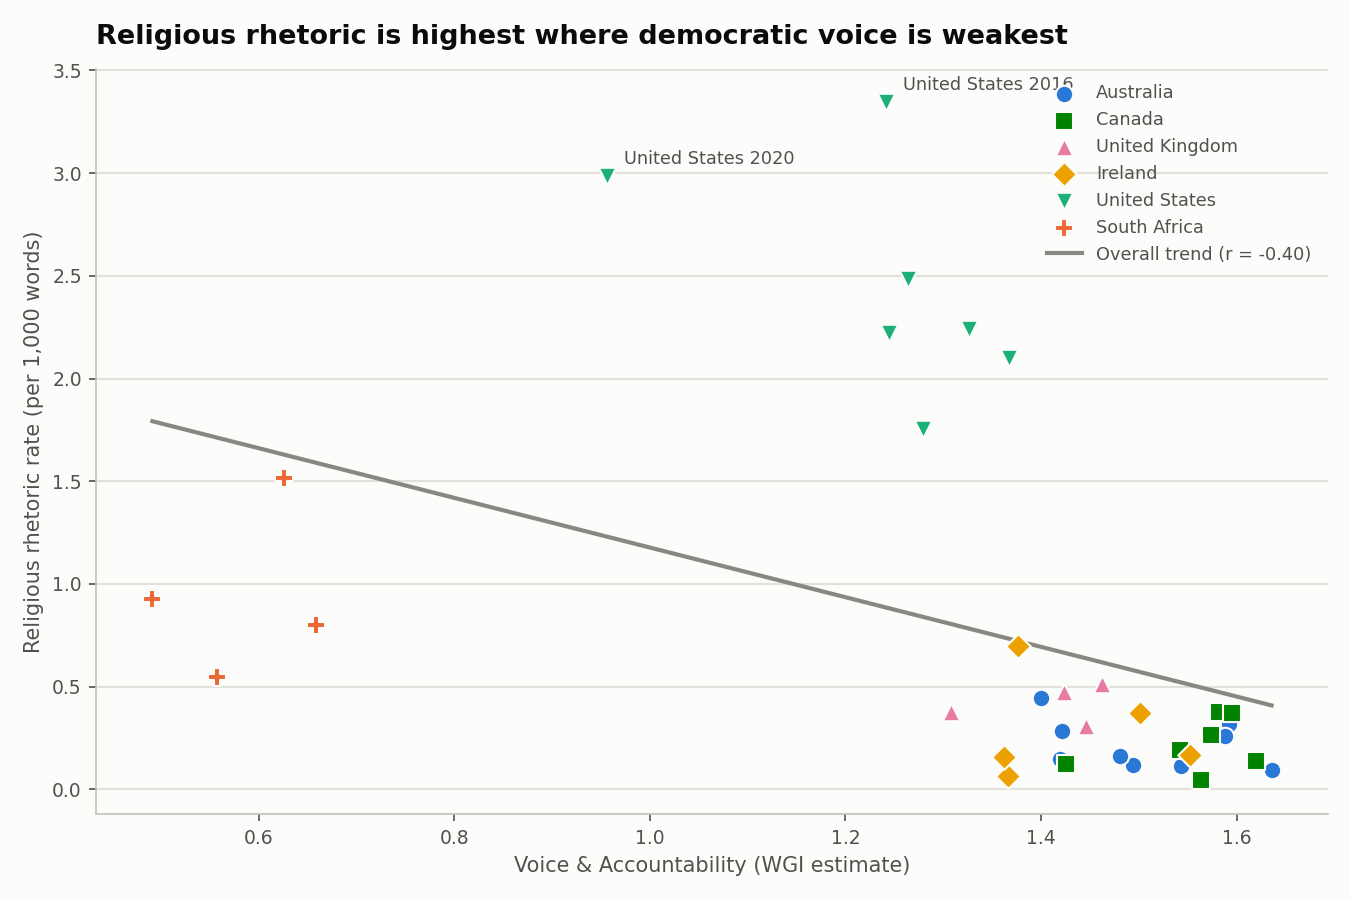

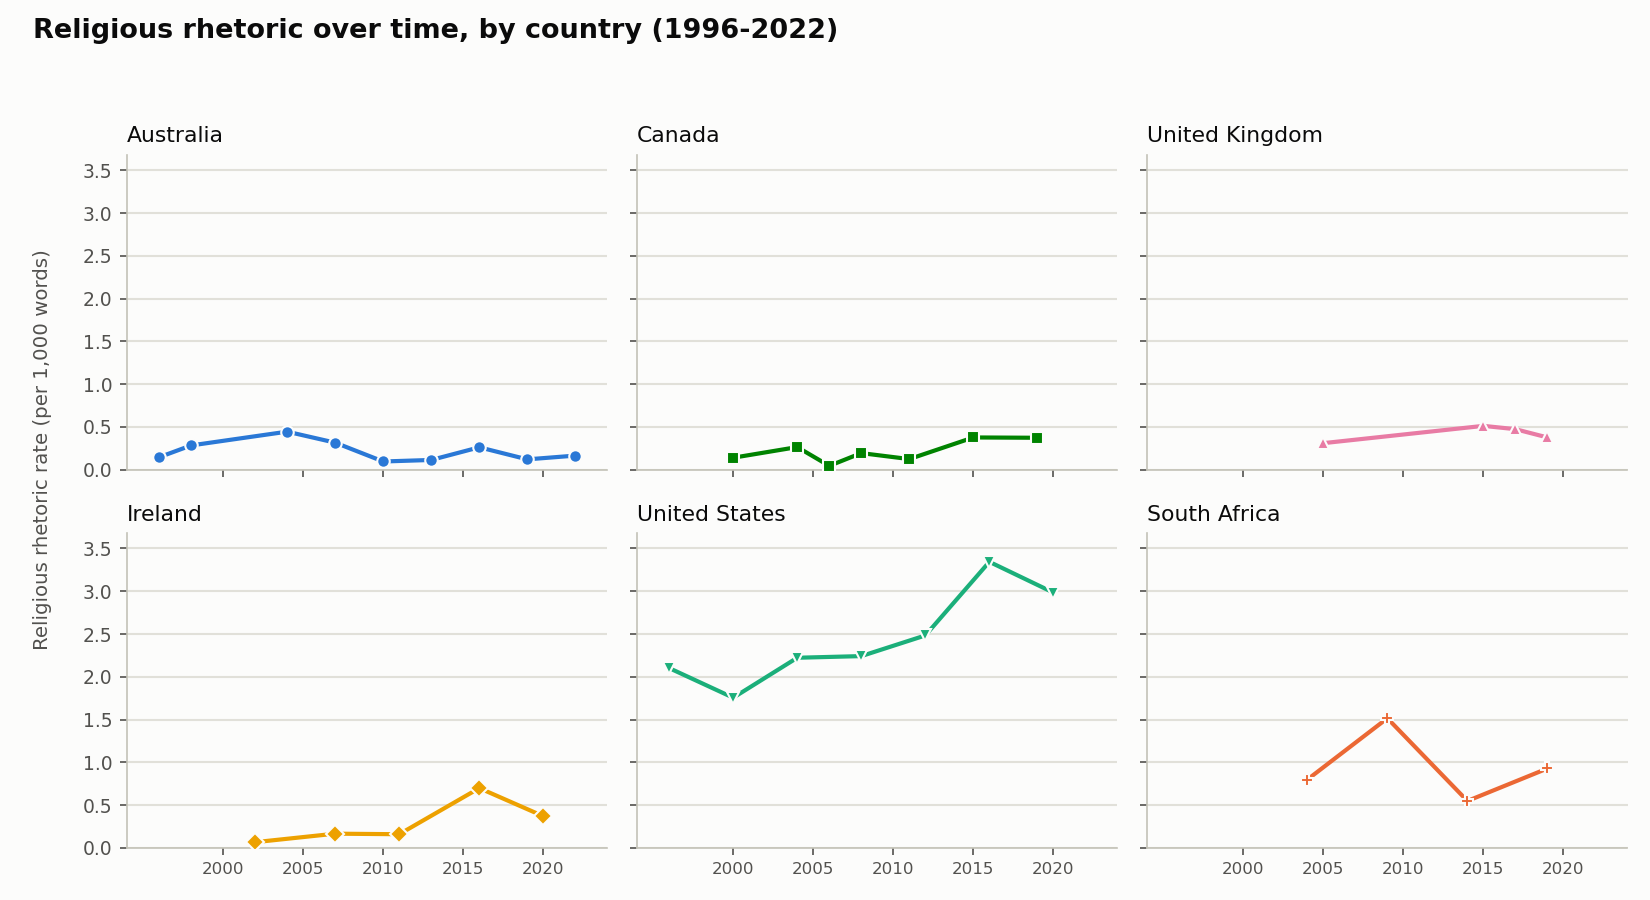

(PosixPath('reports/final_project/rushan-ajizu/figure_1.png'),
 PosixPath('reports/final_project/rushan-ajizu/figure_2.png'))

In [6]:
import graph
graph.run()


## 4. Model Data

### **Guidance**
- Run statistical modeling (such as OLS regression) using functions in your `model.py` file.
- Specify your dependent variable and independent variables clearly.
- Print out the full model summary (e.g., coefficient table, standard errors, R-squared, p-values).
- Summarize your model findings and state whether they support your initial hypothesis.

### **Model Specifications & Interpretation**
- **Model Type:** Panel Ordinary Least Squares (PanelOLS) with Entity (country) Fixed Effects
- **Dependent Variable:** `religious_rhetoric_rate`
- **Independent Variable:** `voice_accountability`
- **Model Fit Metrics:** R-squared (within) = 0.0740, R-squared (overall) = 0.1530, Number of Observations = 36 (6 countries, 21 time periods)
- **Coefficient of Primary Variable (voice_accountability):** Coefficient: -0.9027, Std. Err: 0.5931, T-stat: -1.5221 (p-value: 0.1388)

- **Statistical Significance:** The coefficient is negative, which the hypothesis predicts. But this result is not statistically significant at conventional levels (p = 0.14 > 0.05). The entity fixed effects are themselves strongly justified, so the the F-test for poolability (F = 49.18, p < 0.001) confirms the six countries have very different baseline levels of religious rhetoric that must be controlled for. [Basically, the six countries have genuinely different baseline levels of religious rhetoric that have nothing to do with their V&A score. In Figure 2,US sits consistently around 2-3 per 1,000 words while Australia/Canada/UK/Ireland hover under 0.5 regardless of year. In a single pooled regression without country fixed effects, that baseline gap between countries would get mistaken for part of the V&A effect, biasing the coefficient.]

- **Key Conclusion:** 
Within-country changes in Voice & Accountability over time are associated with lower religious rhetoric, consistent with the initial hypothesis, but the small sample (36 country-years, only 6 entities) and heavy reliance on within-country variation mean the estimate is naturally imprecise and cannot be called statistically significant. The cross-section pattern in Figure 1 (US and South Africa scoring both lowest on democratic voice and highest on religious rhetoric) is suggestive to some degree, sure, but the panel model shows it is not really strongly confirmed once each country's own baseline is held fixed. For a firm conclusion, a set with more country-years, or additional controls, would be needed.



In [8]:
import model
summary = model.run()


=== Regression Results Summary ===
                             PanelOLS Estimation Summary                             
Dep. Variable:     religious_rhetoric_rate   R-squared:                        0.0740
Estimator:                        PanelOLS   R-squared (Between):              0.1339
No. Observations:                       36   R-squared (Within):               0.0740
Date:                     Mon, Jul 20 2026   R-squared (Overall):              0.1530
Time:                             20:04:32   Log-likelihood                   -3.5796
Cov. Estimator:                 Unadjusted                                           
                                             F-statistic:                      2.3168
Entities:                                6   P-value                           0.1388
Avg Obs:                            6.0000   Distribution:                    F(1,29)
Min Obs:                            4.0000                                           
Max Obs:           